#### Linear Regression ####
Linear regression is a fundamental technique in statistics and machine learning that helps model the relationship between variables. In simple terms, it allows us to predict an outcome based on one or more influencing factors. It is widely applied in real estate pricing, sales forecasting, risk assessment, and many other fields.

In this tutorial, we'll explore linear regression in scikit-learn, covering how it works, why it's useful, and how to implement it using scikit-learn. By the end, you'll be able to build and evaluate a linear regression model to make data-driven predictions.

As we have seen, in simple linear regression, the data is modeled using a "best-fit line." The formula for this line is: 

$y = mx + b$ where $m$ is the slope of the line and $b$ is the intercept.

"Multiple linear regression" generalizes the case of one predictor to several predictors (number of rooms, proximity to the ocean, median income of the neighborhood). The formula is generalized to: 

In [544]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import pingouin as pg
from scipy.stats import norm
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import t
from statsmodels.stats.proportion import proportion_confint


In [545]:
url = "https://raw.githubusercontent.com/Bio723-class/example-datasets/master/ABD-lion-noses.csv"
lion = pd.read_csv(url)

print(lion.head())
print(lion.shape)



   proportionBlack  ageInYears
0             0.21         1.1
1             0.14         1.5
2             0.11         1.9
3             0.13         2.2
4             0.12         2.6
(32, 2)


In [546]:
X_train, X_test, y_train, y_test = train_test_split(lion[['proportionBlack']], lion[['ageInYears']], test_size=0.3, random_state=42)

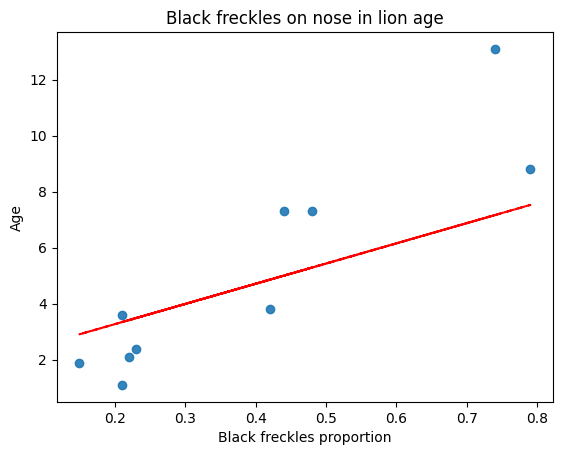

In [547]:
model = LinearRegression()
fitted_model = model.fit(X_train, y_train)
y_pred = fitted_model.predict(X_test)
resid = y_test - y_pred
plt.scatter(X_test, y_test, alpha=0.9)
plt.plot(X_test, y_pred, color = 'red', linestyle='--')
plt.xlabel('Black freckles proportion')
plt.ylabel('Age')
plt.title('Black freckles on nose in lion age')
plt.show()

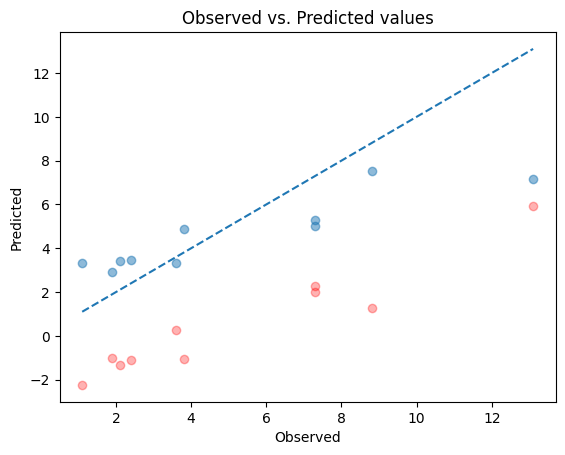

In [548]:
min_val = min(np.min(y_test), np.min(y_pred))
max_val = max(np.max(y_test), np.max(y_pred))

#show line of agreement = y = x, which means it shows how far are our predicted values from what is expected
plt.scatter(y_test, y_pred, alpha=0.5)
plt.scatter(y_test, resid, color='red', alpha=0.3)
plt.plot([min_val, max_val],[min_val, max_val], linestyle='--')
plt.xlabel('Observed')
plt.ylabel('Predicted')
plt.title('Observed vs. Predicted values')
plt.show()

In [549]:
print(f'Our intercept is: {model.intercept_[0]}')
print(f'Our slope is {model.coef_[0,0]}')
#our formula is yi = 0.30404668 + (0.32798477)Xi + ei where ei represents the random variability about the 
#regression line
freckles_percentage = 0.45
sample_lion_age = model.intercept_[0]+ (model.coef_[0,0])*freckles_percentage + 0
print(f'Lion age is {sample_lion_age}')

Our intercept is: 1.8247019709653491
Our slope is 7.220647451520611
Lion age is 5.073993324149624


In [550]:
# now we can try to mutate the data
lion['percentageBlack'] = lion['proportionBlack']*100

In [551]:
X_train, X_test, y_train, y_test = train_test_split(lion[['percentageBlack']], lion[['ageInYears']], test_size=0.3, random_state=42)

We see that our slope changes to 0.07220647451520608, suggesting that the average A g e changes by 0.7220647451520608 years for each increase of 1 unit of p e r c e n t . b l a c k . This example highlights an important point: the magnitude of β is not very useful for deciding on the relative importance of different predictors since it is tied to the scale of measurement.

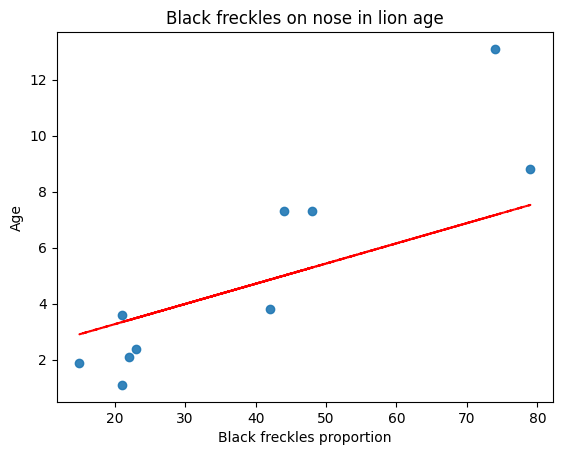

In [552]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
resid = y_test - y_pred

plt.scatter(X_test, y_test, alpha=0.9)
plt.plot(X_test, y_pred, color = 'red', linestyle='--')
plt.xlabel('Black freckles proportion')
plt.ylabel('Age')
plt.title('Black freckles on nose in lion age')
plt.show()

#### Evaluating assumptions ####
We can use our residuals to evaluate our assumptions
- $r_i = Y_i  - \hat{Y}_i$ versus fitted or predicted values $\hat{Y}_i$: <br><br>
a)  the linearity assumption (there should be no patterns as we move from left to right along the x-axis).<br>
b)  the constant variance assumption (the degree of scatter in the residuals above and below the horizontal line at 0 should be the same for all fitted values).
<br><br>This produces four standard diagnostic plots:<br>
- __Residuals__ vs __Fitted__:
    Checks linearity and constant variance (homoscedasticity).<br>
    You want a random cloud of points around zero.
    $residuals = y - \hat{y}$, no difference would mean = 0<br><br>
- __Normal Q-Q__:
    Checks whether residuals are approximately normally distributed.<br>
    Points should lie close to the diagonal line. <br>
- __Scale-Location (Spread-Location)__: 
    Another check for homoscedasticity.
    A roughly horizontal band is ideal.<br>
- __Residuals vs Leverage__:
    Identifies influential observations using Cook's distance.<br>

- Residual = 0 → perfect prediction for that observation.
- Residual > 0 → the model underestimated the observed value.
- Residual < 0 → the model overestimated the observed value.

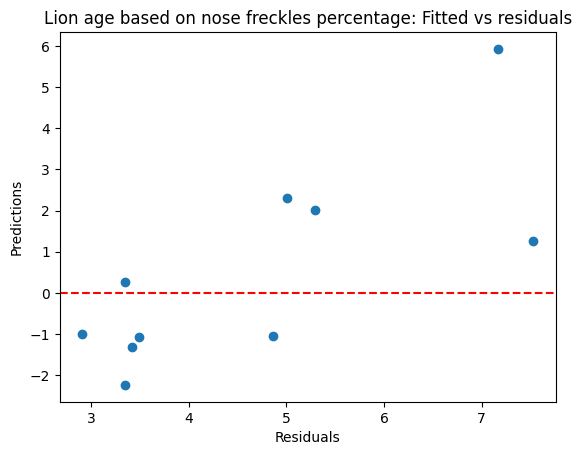

In [553]:
#Residuals vs fitted

plt.scatter(y_pred, resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Residuals')
plt.ylabel('Predictions')
plt.title('Lion age based on nose freckles percentage: Fitted vs residuals')
plt.show()

#### Q-Q residuals ####
A Q-Q (Quantile-Quantile) plot is used to see if a dataset follows a particular theoretical distribution. It works by comparing the quantiles of the observed data to the quantiles of this other distribution. I said ‘theoretical distribution’ to be exact, but often when we create a Q-Q plot, we really think of the normal, or Gaussian, distribution specifically, and we refer to it as a normal Q-Q plot. However, Q-Q plots can also be used to compare data against other distributions, such as exponential, uniform, chi-squared, t-distribution, Poisson distribution, or others, depending on the context. 

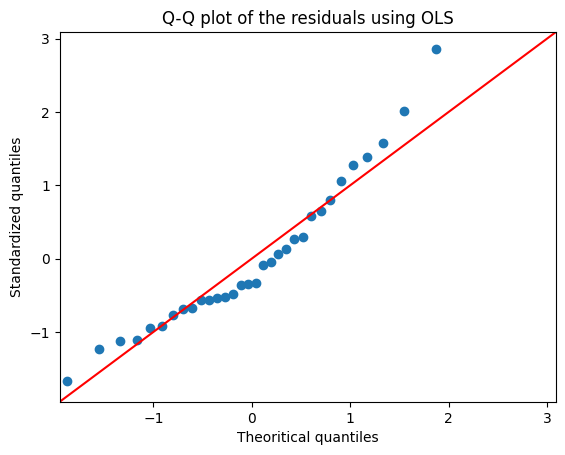

In [554]:
#in order to get the standardized residuals we won't be splitting the data as we'll be checking assumptions
X = lion[['percentageBlack']]
y = lion['ageInYears']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
predicted = model.predict(X)
resids = y - predicted
influence = model.get_influence()
std_resid = influence.resid_studentized_internal

sm.qqplot(std_resid, line ='45')
plt.title('Q-Q plot of the residuals using OLS')
plt.xlabel('Theoritical quantiles')
plt.ylabel('Standardized quantiles')
plt.show()

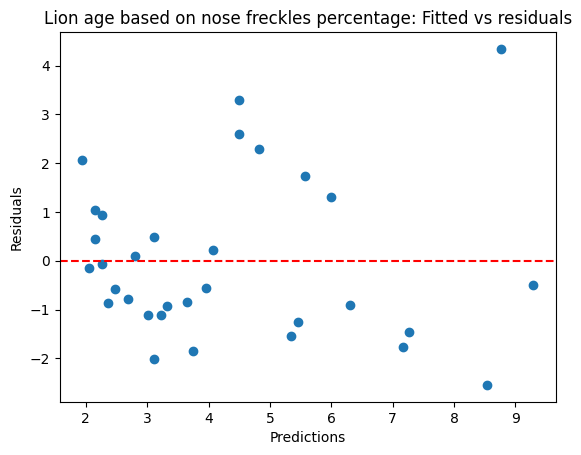

In [555]:
plt.scatter(predicted, resids)
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('Residuals')
plt.xlabel('Predictions')
plt.title('Lion age based on nose freckles percentage: Fitted vs residuals')
plt.show()

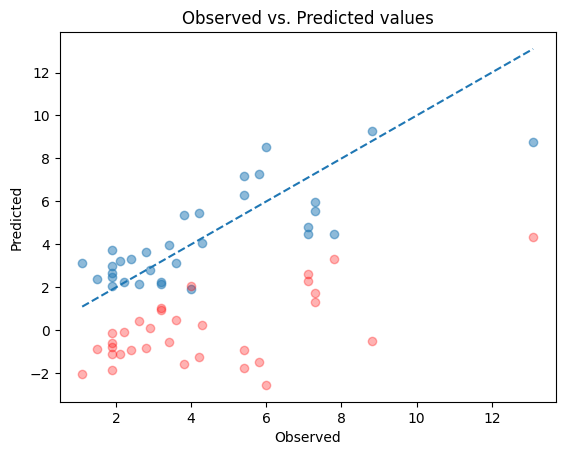

In [556]:
min_val = min(np.min(y), np.min(predicted))
max_val = max(np.max(y), np.max(predicted))

#show line of agreement = y = x, which means it shows how far are our predicted values from what is expected
plt.scatter(y, predicted, alpha=0.5)
plt.scatter(y, resids, color='red', alpha=0.3)
plt.plot([min_val, max_val],[min_val, max_val], linestyle='--')
plt.xlabel('Observed')
plt.ylabel('Predicted')
plt.title('Observed vs. Predicted values')
plt.show()

#### Scale-Location Plot ####

A scale-location plot is a type of plot that displays the fitted values of a regression model along the x-axis and the the square root of the standardized residuals along the y-axis.

When looking at this plot, we check for two things:

1. Verify that the red line is roughly horizontal across the plot. If it is, then the assumption of homoscedasticity is likely satisfied for a given regression model. That is, the spread of the residuals is roughly equal at all fitted values.

2. Verify that there is no clear pattern among the residuals. In other words, the residuals should be randomly scattered around the red line with roughly equal variability at all fitted values.

   

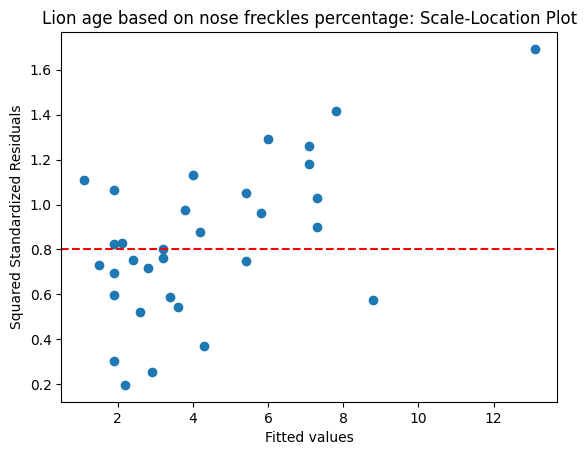

In [557]:
squared_std_resids = np.sqrt(np.abs(std_resid))
plt.scatter(y, squared_std_resids)
plt.axhline(0.8, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Squared Standardized Residuals')
plt.title('Lion age based on nose freckles percentage: Scale-Location Plot')
plt.show()

#### Residuals vs Leverage ####
Lastly, the lower right panel plots residuals versus leverage, a measure of how far away each observation is in “predictor space” from the other observations. Observations with high leverage are often, but not always, highly influential points, meaning that deletion of these points leads to large changes in the regression parameters.

We are going to use this value as leverage to compare to: 0.125


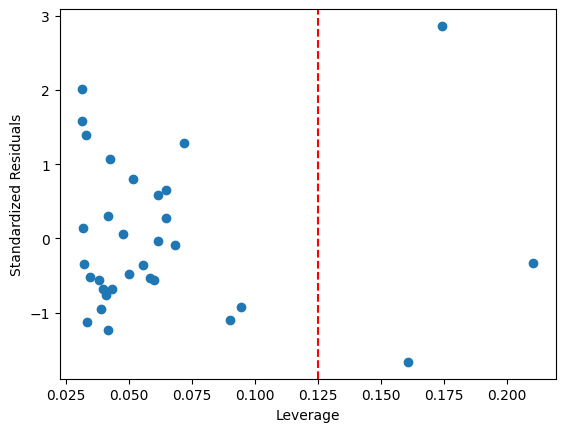

In [558]:
leverage = influence.summary_frame().hat_diag

leverage_to_compare = (2 * 2)/ len(y) 
print(f'We are going to use this value as leverage to compare to: {leverage_to_compare}')
plt.scatter(leverage, std_resid)
plt.xlabel('Leverage')
plt.ylabel('Standardized Residuals')
plt.axvline(leverage_to_compare, color='red', linestyle='--')
plt.show()

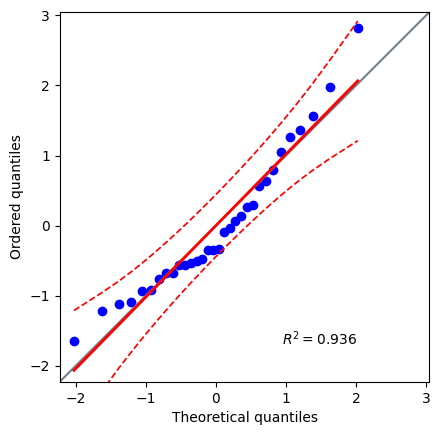

In [559]:
# confidence bands for residuals 
# Could these residuals reasonably have come from a Normal distribution?
# If the residuals are Normal, these points should lie approximately on a straight line.
result = pg.qqplot(std_resid, confidence = 0.95)
plt.show()


#### Normality Of Residuals ####


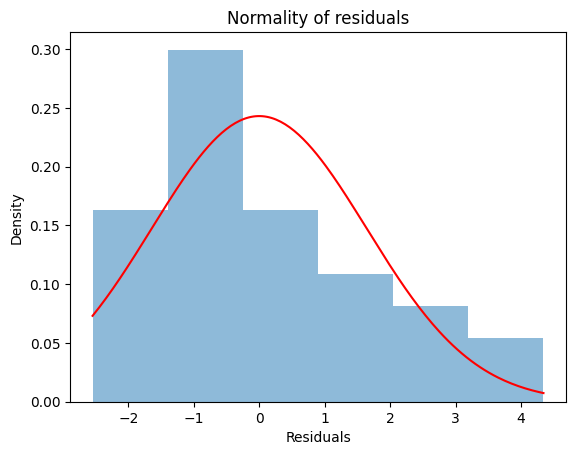

In [560]:
mu = resids.mean()
sigma = resids.std(ddof=1)

x = np.linspace(resids.min(), resids.max(), 200)
y = norm.pdf(x, loc = mu, scale = sigma)

plt.hist(resids, bins='auto' , density=True, alpha=0.5)
plt.plot(x, y, color = 'red')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Normality of residuals')
plt.show()

The intercept (constant term) is necessary for the mathematical model, but it does not have to represent a realistic real-world value. In our case that would be 1.8247019709653496 years when pigmentation is 0. The intercept = the average value of Y when all predictors are set equal to 0 ( E [ Y | X = 0 ] ). The slope = predicted change in Y per unit increase in X

In [561]:
crickets = pd.read_csv('Chirps.csv')

In [562]:
crickets = crickets.rename(columns={'Temperature':'Temperature F'})

In [563]:
crickets.sample(5)

,Temperature F,Chirps
2,63.5,103
6,83.0,195
0,54.5,81
4,72.0,150
1,59.5,97


In [564]:
crickets['Temperature C'] = (crickets['Temperature F'] - 32)*(5/9)

In many cases, interpreting the intercept will require extrapolating outside of the range of the observed data, and therefore the intercept may be misleading or biologically uninterpretable. To quickly illustrate, consider the simple example of predicting the outside temperature from the number of cricket chirps heard per minute (this is a famous data set often used in introductory statistics classes).

In [565]:
print(f"Mean of chirps: {X_train.mean()}")


Mean of chirps: percentageBlack    29.181818
dtype: float64


In [566]:
model_crickets = LinearRegression()
model_crickets.fit(crickets[['Chirps']], crickets[['Temperature F']])
print(f"Intercept: {model_crickets.intercept_[0]}")
print(f"Slope: {model_crickets.coef_[0,0]}")

Intercept: 37.67858381431297
Slope: 0.2306658574648864


A centered variable is created by subtracting its mean from every observation: X centered ​ =X− X ˉ(mean val)

The intercept predicts that the average temperature will be 37 
∘
  degrees when crickets stop chirping. As the scatterplot clearly shows (Figure 1.3), this calculation requires extrapolating well outside of the range of the observed data. In fact, crickets stop chirping well before the temperature hits 37 
∘
  F, but we have no data at lower chirp rates or temperatures to inform the model that this is the case.

Often, it will be helpful to center predictors, which means subtracting the sample mean from all observations. This will create a new variable that has a mean of 0. An advantage of this approach is that our intercept now tells us about the average or expected value of  
Y
  when our original variable,  
X
 , is set to its mean value instead of to 0. For example, we can fit the same model to the cricket data, below, but after having subtracted the mean number of Chirps in the data set.

In [567]:
# A centered variable is created by subtracting its mean from every observation:
crickets['Centered Chirps'] = crickets['Chirps'] - crickets['Chirps'].mean()
print(f'The centered values have a mean of : {crickets['Centered Chirps'].mean()}')
model_crickets = LinearRegression()
model_crickets.fit(crickets[['Centered Chirps']], crickets[['Temperature F']])
print(f"Intercept: {model_crickets.intercept_[0]}")
print(f"Slope: {model_crickets.coef_[0,0]}")

The centered values have a mean of : 0.0
Intercept: 68.35714285714286
Slope: 0.2306658574648864


#### Assumptions about Linear Regression ####
- Homogeneity of variance (constancy in the scatter of observations above and below the line);<br>
  $var(\epsilon_i) = var(X_i|X_j) = \sigma^2$
- Linearity $E[Y_i|X_i] = \mu_i = \beta_0 + X_i\beta_1$ which means that y depends on X and is given by the polynomial $\beta_0 + X_i\beta_1$
- Normality or $\epsilon_i$ or equvalently $Y_i|X_i$ has a Gaussian distribution
- Independence of the errors: Correlation ( $ϵ i , ϵ j ) = 0 for all pairs of observations i and j . This means that knowing how far observation i will be from the true regression line tells us nothing about how far observation j will be from the regression line.

#### Statistical Inference: Sampling Distributions ####

In a regression model, the error term ε is treated as a random variable. When you simulate data, you generate random values from the assumed error distribution.

In [568]:
#simulation
proportionBlack = lion['proportionBlack']
coefficients = [1.8247019709653496, 0.07220647451520608]
#sigma is available
print(f'Sigma: {sigma}')
epsilon = np.random.normal(size = len(lion), loc = 0, scale = sigma)
y = coefficients[0] + (proportionBlack*coefficients[1]) + epsilon

X_sim = sm.add_constant(lion[['proportionBlack']])
ols_sim = sm.OLS(y, X_sim).fit()
print(ols_sim.summary())

ols_rse_ms = np.sqrt(ols_sim.mse_resid)
print(f"Residual squared error: {ols_rse_ms}")
print("True coefficients:")
print(coefficients)

print("\nEstimated coefficients:")
print(ols_sim.params)

Sigma: 1.6416279234813282
                            OLS Regression Results                            
Dep. Variable:        proportionBlack   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                 -0.013
Method:                 Least Squares   F-statistic:                    0.5955
Date:                Sat, 11 Jul 2026   Prob (F-statistic):              0.446
Time:                        18:02:34   Log-Likelihood:                -63.745
No. Observations:                  32   AIC:                             131.5
Df Residuals:                      30   BIC:                             134.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           

In [569]:
print(len(lion))
print(proportionBlack.describe())
print(ols_sim.params)

32
count    32.000000
mean      0.322187
std       0.198555
min       0.100000
25%       0.165000
50%       0.265000
75%       0.432500
max       0.790000
Name: proportionBlack, dtype: float64
const              2.165468
proportionBlack   -1.278789
dtype: float64


As we might expect, the estimates of our parameters are close to the true values, but not identical to them (note the estimate of  
σ
  is given by the Residual standard error, equal to 1.475). We can repeat this process, and each time we simulate a new data set, we will get a different set of parameter estimates. This is a good time to introduce the concept of a for loop, which will allow us to repeat this simulation process many times and store the results from each simulation.

Let’s use a for loop to: 
1. Generate 5000 data sets using the our code we wrote for simulating observations from the linear regression model with true parameters ( β 0 , β 1 , σ ) = (0.88, 10.65, 1.67)
2. Fit a linear regression model to each of these data sets
3. Store ^ β 1 in a 5000 x 1 matrix labeled beta.hat

In [570]:
betas = []
for i in range(0,5000):
    epsilon = np.random.normal(size = len(lion), loc = 0, scale = sigma)
    y = coefficients[0] + (proportionBlack*coefficients[1]) + epsilon
    X_sim = sm.add_constant(lion[['proportionBlack']])
    results = sm.OLS(y, X_sim).fit()
    beta_hat = results.params.proportionBlack
    betas.append(beta_hat)
    
    

In [571]:
#This gives an estimate of the standard error of β^
std_beta_hat = np.std(betas,ddof=1)
print(f"Std of beta hat from our simulation is: {std_beta_hat}")

Std of beta hat from our simulation is: 1.4681156809609353


This standard error is what is reported in the Std. Error column of the regression output (but, it is calculated analytically rather than through simulation by the lm function). It tells us how much we should expect our estimates to vary across repeated trials, where a trial represents collecting a new data set of the same size as the original data set and then fitting a linear regression model to that data set. This variability provides us with a useful measure to quantify uncertainty associated with our estimates, ^ β 0 and ^ β 1 .

####  Sampling distribution of the t-statistic ####

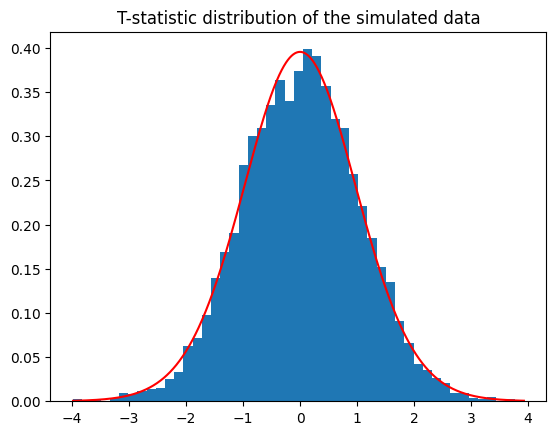

In [572]:
#Class exercise: sampling distribution of the t-statistic

betas = []
t_statistics = []
slope = coefficients[1];
intercept = coefficients[0]
confidence_intervals_upper = [];
confidence_intervals_lower = [];
number_of_successes = 0; # for coverage
contains_per_sample = []
for i in range(0,5000):
    epsilon = np.random.normal(size = len(lion), loc = 0, scale = sigma)
    y = intercept + (proportionBlack*slope) + epsilon
    X_sim = sm.add_constant(lion[['proportionBlack']])
    results = sm.OLS(y, X_sim).fit()
    beta_hat = results.params.proportionBlack
    se_hat = results.bse.proportionBlack
    conf = results.conf_int(alpha=0.05)
    pb_conf = conf.loc['proportionBlack']
    
    lower = pb_conf[0]
    upper = pb_conf[1]    

    confidence_intervals_lower.append(lower)
    confidence_intervals_upper.append(upper)
    
    contains_true_beta = (lower <= slope) and (slope <= upper)
    
    if contains_true_beta==True:
        number_of_successes = number_of_successes + 1

    contains_per_sample.append(contains_true_beta)
    betas.append(beta_hat)
    t_statistic = (beta_hat - slope) / (se_hat)
    t_statistics.append(t_statistic)

student_distribution = len(lion)-2
x = np.linspace(min(t_statistics), max(t_statistics), 1000)
plt.hist(t_statistics,bins = 'fd', density=True)
plt.plot(x, t.pdf(x, df=student_distribution), "r")
plt.title('T-statistic distribution of the simulated data')
plt.show()

#### Confidence Intervals ####

A confidence interval for a parameter is an interval computed using sample data by a method that will contain the parameter for a specified proportion of all samples (assuming the sample is representative of the population). The success rate (proportion of all samples whose intervals contain the parameter) is known as the confidence level or coverage rate. For example, a 95% confidence interval will contain the true parameter for 95% of all samples that we could obtain if we were to repeatedly sample from the same population or repeatedly generate data sets using the same data-generating model.

The key to understanding confidence intervals is to recognize that:

the parameter we are trying to estimate is a fixed unknown (i.e., it is not varying across samples)
the endpoints of our confidence interval are random and will change every time we collect a new data set (the endpoints themselves actually have a sampling distribution!)

In [573]:
# how do we get the confidence interval and the quantiles?
quantiles = np.quantile(t_statistics, [0.025, 0.975])
print(quantiles)
print(t.interval(0.975, df = 30))

[-1.97159749  2.01181438]
(np.float64(-2.3595624587009194), np.float64(2.3595624587009216))


So, we know that 95% of the time when we collect and fit a linear regression model (assuming ),  
^
β
−
β
ˆ
S
E
(
^
β
)
  will fall between -2.07 and 2.008.

#### Confidence Interval Definition ####
A confidence interval for a parameter is an interval computed from sample data by a method that will capture the parameter for a specified proportion of all samples.Notice something subtle:

The first probability statement is about where the random estimator 
β
^
	​

 falls relative to the fixed β.
The second probability statement is written in terms of whether the random interval contains the fixed β.

These two statements are mathematically equivalent. They describe the same event, just written differently.
So our simulations demonstrate both facts at once:

- About 95% of the standardized estimation errors fall within the critical t-values.
- About 95% of the confidence intervals contain the true parameter.

Those are not two different ideas—they are the same event expressed in two different ways through algebra. That's the key insight behind confidence intervals.

In [574]:
coverage = number_of_successes / 5000
print(f'Coverage: {coverage}')
calc = proportion_confint(number_of_successes, 5000, alpha=0.05, method="wilson")
print(f'Coverage using wilson method: {calc}')

Coverage: 0.956
Coverage using wilson method: (0.9499564961638414, 0.9613433596622665)


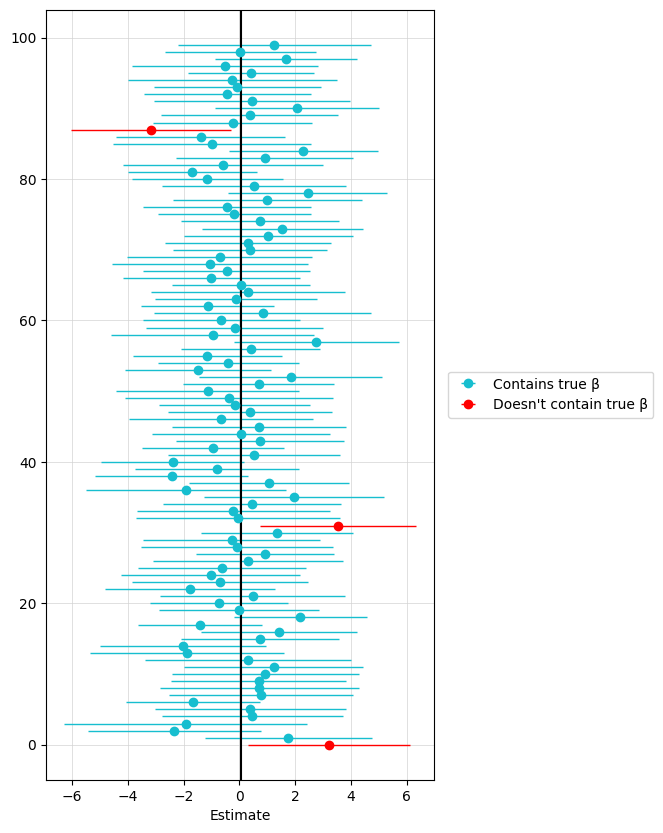

In [575]:
contains = np.array(contains_per_sample[:100])

estimates = np.array(betas[:100])
lower = np.array(confidence_intervals_lower[:100])
upper  = np.array(confidence_intervals_upper[:100])
y = np.arange(len(estimates))

plt.figure(figsize=(5,10))

#plot contains beta

estimates_contains = estimates[contains]
lower_contains = lower[contains]
upper_contains = upper[contains]
y_contains = y[contains]


plt.errorbar(
        estimates_contains,
        y_contains,
        xerr=[estimates_contains - lower_contains, upper_contains - estimates_contains],
        fmt='o',
        linewidth=1,
        capsize=0,
        color='tab:cyan',
        label="Contains true β"
    )

estimates_contains_not = estimates[~contains]
lower_contains_not = lower[~contains]
upper_contains_not = upper[~contains]
y_contains_not = y[~contains]


#plot those which do not contain beta
plt.grid(color='lightgrey', linestyle='-', linewidth=0.5)
plt.errorbar(
        estimates_contains_not,
        y_contains_not,
        xerr=[estimates_contains_not - lower_contains_not, upper_contains_not - estimates_contains_not],
        fmt='o',
        linewidth=1,
        capsize=0,
        color='red',
        label="Doesn't contain true β"
    )
plt.axvline(slope, color="black")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)
plt.xlabel('Estimate')
plt.show()

In [583]:
#prediction interval - case 1
print(model)
print(model.model.exog.shape)
print(model.model.exog_names)

(32, 2)
['const', 'percentageBlack']


In [592]:
# "What is the average age of all lions with this proportion of black on their noses?"
new_data = pd.DataFrame()
new_data['percentageBlack'] = [40]
new_data['const'] = [1]

pred = model.predict(new_data)
prediction = model.get_prediction(new_data)
summary = prediction.summary_frame(alpha=0.05)


In [594]:
summary

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,35.266719,22.739779,-11.174105,81.707544,-11.298988,81.832427


In [599]:
# "What is the average age of all lions with this proportion of black on their noses?"
print(f'Confidence interval : [{summary.mean_ci_lower[0]}, {summary.mean_ci_upper[0]}]')

Confidence interval : [-11.174104825500642, 81.70754367670256]


In [595]:
pred

0    35.266719
dtype: float64

In [600]:
#prediction interval This gives a prediction interval for a single future observation.
print(f'Prediction interval : [{summary.obs_ci_lower[0]}, {summary.obs_ci_upper[0]}]')

Prediction interval : [-11.298987965999103, 81.83242681720101]


In [ ]:
### Quite crazy ?!?!?!?!